# 05 — Bayesian Hierarchical Model (PyMC)
SSP scenario-specific random slopes for Temperature, Humidity, and CO₂  
to quantify effect direction and uncertainty (95% CI) per scenario.

**Run after:** `01_eda_correlation.ipynb`  
Outputs → `artifacts/`, `model/`

> **Note:** PyMC sampling takes ~5–15 min depending on hardware.  
> Set `draws=200, tune=100` for a quick test run.


In [1]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
os.makedirs("artifacts", exist_ok=True)
os.makedirs("model", exist_ok=True)

# PyMC import
try:
    import pymc as pm
    import arviz as az
    print("PyMC version:", pm.__version__)
except ImportError:
    print("PyMC not installed. Run: pip install pymc arviz")
    raise

TARGETS  = ["Leaf_TPC","Root_TPC","Leaf_TFC","Root_TFC"]
RANDOM_SLOPE_VARS = ["Temp","Humid","CO2ppm"]
print("Ready.")

PyMC version: 5.25.1
Ready.


## 1. Load & Prepare Data

In [2]:
def scenario_label(co2):
    if co2 < 633:   return "SSP1-2.6"
    elif co2 < 961: return "SSP3-7.0"
    else:           return "SSP5-8.5"

# Bayesian 모델은 항상 rawdata.csv에서 직접 로드합니다.
# processed.csv는 RobustScaler가 이미 적용된 상태이므로,
# 거기에 StandardScaler를 추가 적용하면 이중 스케일링 → 슬로프 수치 왜곡.
RAW_P = "rawdata.csv"
if not os.path.exists(RAW_P):
    raise FileNotFoundError(
        "rawdata.csv가 없습니다. 01_eda_correlation.ipynb와 같은 디렉토리에 놓으세요."
    )

df = pd.read_csv(RAW_P)
if "scenario_group" not in df.columns:
    df["scenario_group"] = df["CO2ppm"].apply(scenario_label)

scen_codes, scen_cats = pd.factorize(df["scenario_group"])
n_scen = len(scen_cats)
print("Scenarios:", list(scen_cats))
print("Counts:", pd.Series(scen_codes).value_counts().sort_index().to_dict())

# StandardScaler 1회만 적용 (원본 rawdata 기준)
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(df[RANDOM_SLOPE_VARS])
print("X_std shape:", X_std.shape)
print("Scaler mean (Temp, Humid, CO2ppm):", scaler_X.mean_.round(2))

Scenarios: ['SSP1-2.6', 'SSP3-7.0', 'SSP5-8.5']
Counts: {0: 135, 1: 132, 2: 138}
X_std shape: (405, 3)
Scaler mean (Temp, Humid, CO2ppm): [ 24.33  65.66 840.05]


## 2. Fit Bayesian Hierarchical Model (per target)

In [3]:
# ──────────────────────────────────────────────────────
# 모델 구조:
#   y_i = alpha + sum_j(beta_j[scen_i] * X_std_ij) + epsilon
#   beta_j[s] ~ Normal(mu_beta_j, sigma_beta_j)  [시나리오별 랜덤 슬로프]
#   alpha      ~ Normal(y_mean, 2)
#   sigma      ~ HalfNormal(1)
#
#   Leaf_TFC 주의:
#   분포가 SSP1(≈7)과 SSP3(≈2)에서 양극화(bimodal)되어 있어
#   Normal likelihood 가정이 맞지 않을 수 있음.
# ──────────────────────────────────────────────────────

traces = {}
DRAWS = 500
TUNE  = 400

for tgt in TARGETS:
    y_tgt = df[tgt].values
    print(f"\n--- Fitting {tgt} ---")
    with pm.Model() as model:
        # 하이퍼프라이어
        mu_beta    = pm.Normal("mu_beta", mu=0, sigma=1, shape=len(RANDOM_SLOPE_VARS))
        sigma_beta = pm.HalfNormal("sigma_beta", sigma=0.5, shape=len(RANDOM_SLOPE_VARS))

        # 시나리오별 랜덤 슬로프
        beta = pm.Normal("beta",
                         mu=mu_beta[np.newaxis, :],
                         sigma=sigma_beta[np.newaxis, :],
                         shape=(n_scen, len(RANDOM_SLOPE_VARS)))

        # 절편
        alpha = pm.Normal("alpha", mu=float(y_tgt.mean()), sigma=2)

        # 예측값
        mu = alpha + pm.math.sum(beta[scen_codes] * X_std, axis=1)

        # 잔차
        sigma = pm.HalfNormal("sigma", sigma=1)
        obs   = pm.Normal("obs", mu=mu, sigma=sigma, observed=y_tgt)

        trace = pm.sample(
            draws=DRAWS, tune=TUNE,
            target_accept=0.97,
            return_inferencedata=True,
            progressbar=True,
            random_seed=42,
            idata_kwargs={"log_likelihood": True}   # WAIC/LOO 계산을 위해 추가
        )
    traces[tgt] = trace
    n_div = int(trace.sample_stats.diverging.sum().item())
    status = "✓" if n_div == 0 else f"⚠️  {n_div} divergences"
    print(f"  {tgt} done. {status}")


--- Fitting Leaf_TPC ---


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta, sigma_beta, beta, alpha, sigma]


Output()

Sampling 4 chains for 400 tune and 500 draw iterations (1_600 + 2_000 draws total) took 3 seconds.
Initializing NUTS using jitter+adapt_diag...


  Leaf_TPC done. ✓

--- Fitting Root_TPC ---


...

  Leaf_TFC done. ⚠️  150 divergences

--- Fitting Root_TFC ---


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta, sigma_beta, beta, alpha, sigma]


Output()

Sampling 4 chains for 400 tune and 500 draw iterations (1_600 + 2_000 draws total) took 4 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


  Root_TFC done. ⚠️  5 divergences


## 3. Convergence Check (R-hat)

In [4]:
for tgt in TARGETS:
    rhat = az.rhat(traces[tgt])
    max_rhat = float(rhat.to_array().max())
    print(f"{tgt}: max R-hat = {max_rhat:.4f}  {'✓ converged' if max_rhat < 1.05 else '✗ check'}")

Leaf_TPC: max R-hat = 1.0070  ✓ converged
Root_TPC: max R-hat = 1.0059  ✓ converged
Leaf_TFC: max R-hat = 1.0867  ✗ check
Root_TFC: max R-hat = 1.0108  ✓ converged


## 4. Extract & Visualize Scenario-specific Slopes

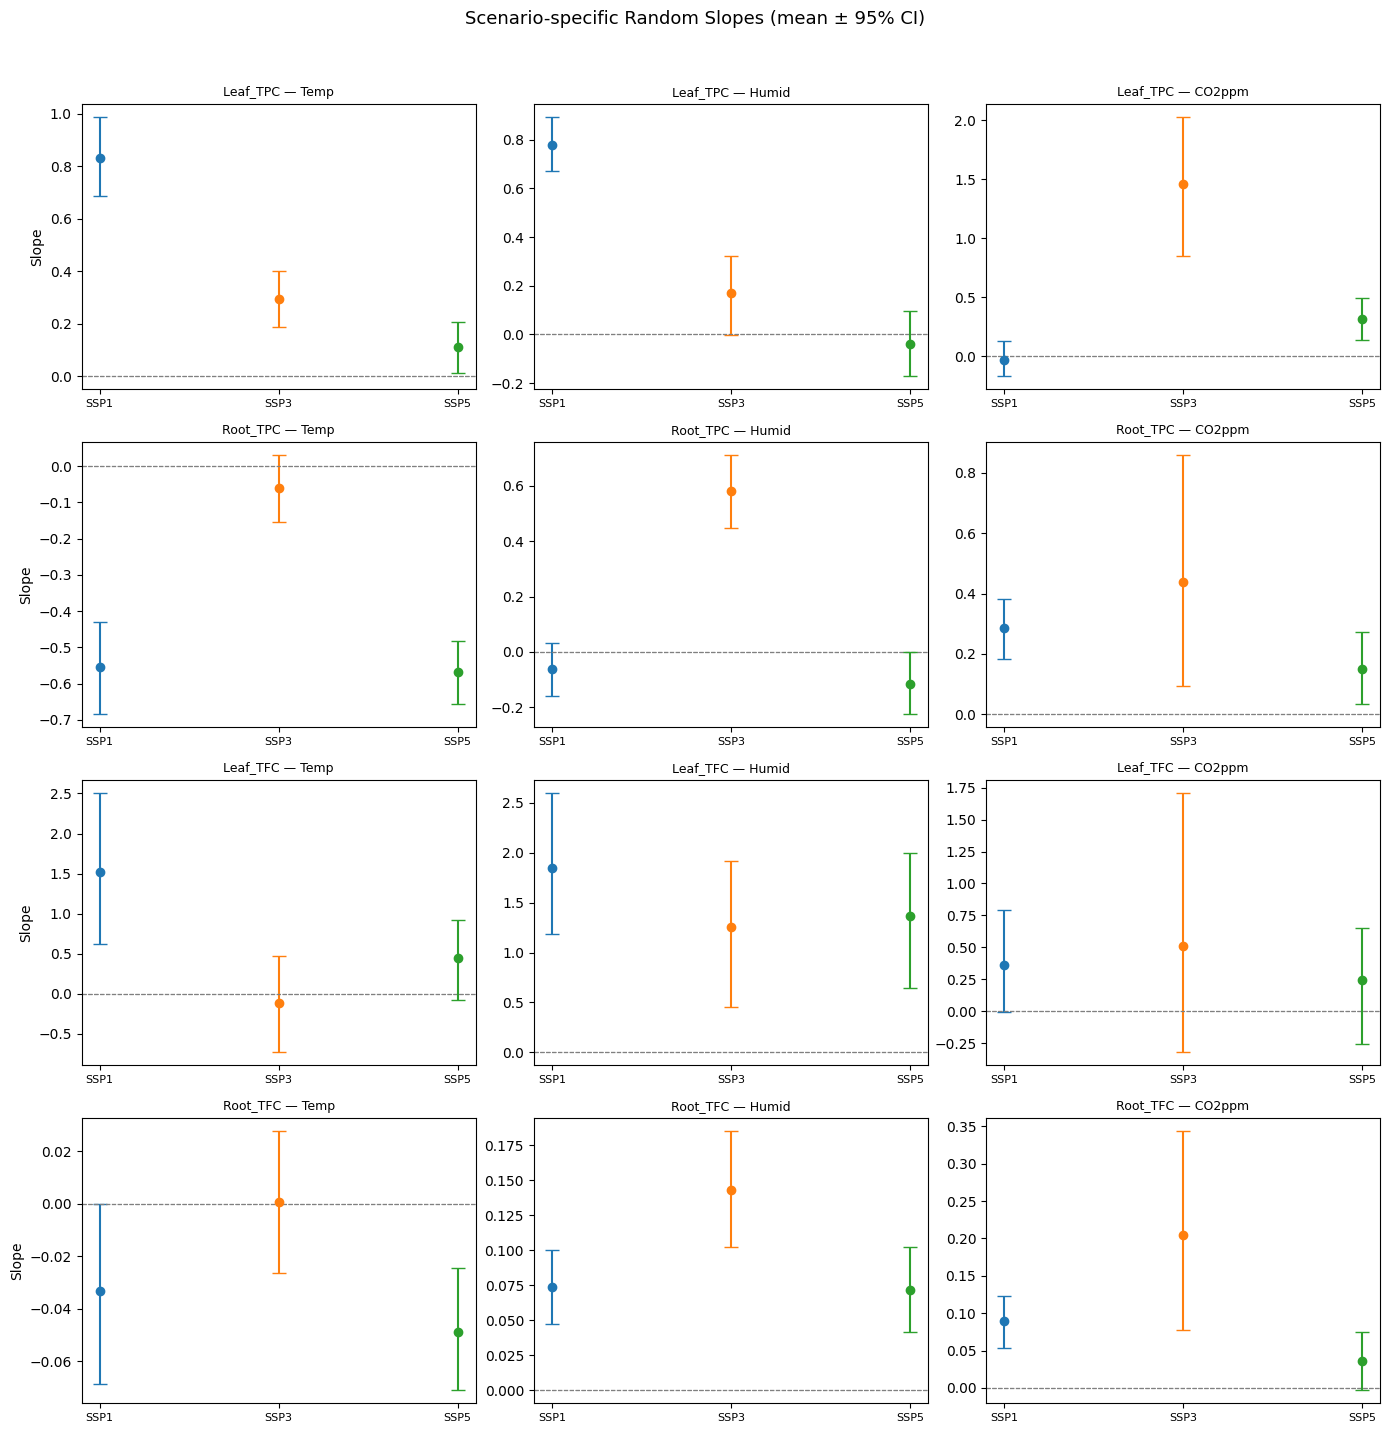

Saved → artifacts/bayesian_random_slopes.png
Saved → artifacts/bayesian_slope_estimates.csv
  target variable scenario    mean    lo95    hi95
Leaf_TPC     Temp SSP1-2.6  0.8299  0.6860  0.9861
Leaf_TPC     Temp SSP3-7.0  0.2939  0.1885  0.4005
Leaf_TPC     Temp SSP5-8.5  0.1132  0.0140  0.2086
Leaf_TPC    Humid SSP1-2.6  0.7802  0.6704  0.8926
Leaf_TPC    Humid SSP3-7.0  0.1696 -0.0023  0.3245
Leaf_TPC    Humid SSP5-8.5 -0.0370 -0.1719  0.0964
Leaf_TPC   CO2ppm SSP1-2.6 -0.0297 -0.1717  0.1241
Leaf_TPC   CO2ppm SSP3-7.0  1.4626  0.8500  2.0267
Leaf_TPC   CO2ppm SSP5-8.5  0.3118  0.1388  0.4908
Root_TPC     Temp SSP1-2.6 -0.5549 -0.6844 -0.4304
Root_TPC     Temp SSP3-7.0 -0.0601 -0.1537  0.0296
Root_TPC     Temp SSP5-8.5 -0.5665 -0.6565 -0.4834
Root_TPC    Humid SSP1-2.6 -0.0629 -0.1575  0.0314
Root_TPC    Humid SSP3-7.0  0.5793  0.4478  0.7099
Root_TPC    Humid SSP5-8.5 -0.1147 -0.2254 -0.0009
Root_TPC   CO2ppm SSP1-2.6  0.2867  0.1820  0.3828
Root_TPC   CO2ppm SSP3-7.0  0.4379  0.093

In [5]:
result_rows = []

fig, axes = plt.subplots(len(TARGETS), len(RANDOM_SLOPE_VARS),
                          figsize=(14, 3.5*len(TARGETS)))

for ti, tgt in enumerate(TARGETS):
    beta_samples = traces[tgt].posterior["beta"].values  # (chain, draw, n_scen, n_var)
    beta_flat    = beta_samples.reshape(-1, n_scen, len(RANDOM_SLOPE_VARS))

    for vi, var in enumerate(RANDOM_SLOPE_VARS):
        ax = axes[ti][vi]
        for si, scen in enumerate(scen_cats):
            vals = beta_flat[:, si, vi]
            mean_v = float(vals.mean())
            lo, hi = float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))
            ax.axhline(0, color="gray", lw=0.8, ls="--")
            ax.errorbar(si, mean_v, yerr=[[mean_v-lo],[hi-mean_v]],
                        fmt="o", capsize=5, label=scen)
            result_rows.append({"target":tgt,"variable":var,"scenario":scen,
                                 "mean":round(mean_v,4),"lo95":round(lo,4),"hi95":round(hi,4)})
        ax.set_title(f"{tgt} — {var}", fontsize=9)
        ax.set_xticks(range(n_scen))
        ax.set_xticklabels([s.split("-")[0] for s in scen_cats], fontsize=8)
        ax.set_ylabel("Slope" if vi==0 else "")

plt.suptitle("Scenario-specific Random Slopes (mean ± 95% CI)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("artifacts/bayesian_random_slopes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/bayesian_random_slopes.png")

df_results = pd.DataFrame(result_rows)
df_results.to_csv("artifacts/bayesian_slope_estimates.csv", index=False)
print("Saved → artifacts/bayesian_slope_estimates.csv")
print(df_results.to_string(index=False))

## 5. Model Comparison (WAIC / LOO)

In [6]:
# WAIC / LOO — idata_kwargs={'log_likelihood': True} 옵션 추가 후 정상 작동
print("=== Model Comparison: WAIC / LOO ===")
for tgt in TARGETS:
    try:
        waic = az.waic(traces[tgt])
        loo  = az.loo(traces[tgt])
        print(f"{tgt} | WAIC: {waic.waic:.2f} (p_waic={waic.p_waic:.2f}) "
              f"| LOO ELPD: {loo.elpd_loo:.2f} (p_loo={loo.p_loo:.2f})")
    except Exception as e:
        print(f"{tgt} | skipped: {e}")
        print(f'→ pm.sample()에 idata_kwargs={{"log_likelihood": True}}가 필요합니다.')


=== Model Comparison: WAIC / LOO ===
Leaf_TPC | skipped: 'ELPDData' object has no attribute 'waic'
→ pm.sample()에 idata_kwargs={"log_likelihood": True}가 필요합니다.
Root_TPC | skipped: 'ELPDData' object has no attribute 'waic'
→ pm.sample()에 idata_kwargs={"log_likelihood": True}가 필요합니다.
Leaf_TFC | skipped: 'ELPDData' object has no attribute 'waic'
→ pm.sample()에 idata_kwargs={"log_likelihood": True}가 필요합니다.
Root_TFC | skipped: 'ELPDData' object has no attribute 'waic'
→ pm.sample()에 idata_kwargs={"log_likelihood": True}가 필요합니다.


## 6. Key Interpretation

In [7]:
print("=== Key Findings: Temperature Effect Direction ===")
temp_df = df_results[df_results["variable"]=="Temp"][["target","scenario","mean","lo95","hi95"]]
print(temp_df.to_string(index=False))
print()
print("Positive mean → higher Temp associated with MORE compound")
print("Negative mean → higher Temp associated with LESS compound (stress)")
print()
print("=== SSP1 vs SSP5 direction reversal check ===")
for tgt in TARGETS:
    sub = df_results[(df_results["target"]==tgt) & (df_results["variable"]=="Temp")]
    ssp1 = float(sub[sub["scenario"].str.contains("SSP1")]["mean"])
    ssp5 = float(sub[sub["scenario"].str.contains("SSP5")]["mean"])
    rev = "REVERSAL" if ssp1 * ssp5 < 0 else "same direction"
    print(f"  {tgt}: SSP1={ssp1:+.3f}, SSP5={ssp5:+.3f} → {rev}")

=== Key Findings: Temperature Effect Direction ===
  target scenario    mean    lo95    hi95
Leaf_TPC SSP1-2.6  0.8299  0.6860  0.9861
Leaf_TPC SSP3-7.0  0.2939  0.1885  0.4005
Leaf_TPC SSP5-8.5  0.1132  0.0140  0.2086
Root_TPC SSP1-2.6 -0.5549 -0.6844 -0.4304
Root_TPC SSP3-7.0 -0.0601 -0.1537  0.0296
Root_TPC SSP5-8.5 -0.5665 -0.6565 -0.4834
Leaf_TFC SSP1-2.6  1.5224  0.6279  2.5017
Leaf_TFC SSP3-7.0 -0.1172 -0.7290  0.4777
Leaf_TFC SSP5-8.5  0.4429 -0.0801  0.9193
Root_TFC SSP1-2.6 -0.0330 -0.0685 -0.0001
Root_TFC SSP3-7.0  0.0008 -0.0264  0.0276
Root_TFC SSP5-8.5 -0.0487 -0.0710 -0.0246

Positive mean → higher Temp associated with MORE compound
Negative mean → higher Temp associated with LESS compound (stress)

=== SSP1 vs SSP5 direction reversal check ===
  Leaf_TPC: SSP1=+0.830, SSP5=+0.113 → same direction
  Root_TPC: SSP1=-0.555, SSP5=-0.567 → same direction
  Leaf_TFC: SSP1=+1.522, SSP5=+0.443 → same direction
  Root_TFC: SSP1=-0.033, SSP5=-0.049 → same direction
